# Test 12: Анализ вклада компонентов активации

**Вопрос:** При a=1 sin(x) почти линейен на малых x. Вносит ли sin реальный вклад или вся работа на tanh?

**План:**
- sin(1x) + 0.5·tanh(4x) — полная активация при a=1 (победитель теста 11)
- 0.5·tanh(4x) — только tanh-компонента
- tanh(4x) — tanh без весового коэффициента
- sin(1x) — только sin-компонента
- sin(8x) + 0.5·tanh(4x) — оригинальная активация (a=8)
- ReLU + TopK — baseline

**Данные:** MNIST, N=5 прогонов, 10 эпох

**Метрики:** val_loss, dead neurons, variance

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy import stats
import json
from datetime import datetime

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# === Базовые компоненты ===

class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def make_activation(a=1.0, w=0.5, b=4.0):
    @tf.function
    def activation(x):
        return tf.sin(a * x) + w * tf.tanh(b * x)
    return activation


def build_chaos_ae(act_fn, image_size=(28, 28), latent_dim=128, k_active=32):
    output_dim = int(np.prod(image_size))
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256)(x)
    x = layers.Activation(act_fn)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, name='latent_pre')(x)
    x = layers.Activation(act_fn)(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256)(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(act_fn)(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(output_dim, activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def build_topk_relu(image_size=(28, 28), latent_dim=128, k_active=32):
    output_dim = int(np.prod(image_size))
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, activation='relu', name='latent_pre')(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256, activation='relu')(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(output_dim, activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def analyze_latent(encoder, images, threshold=1e-6):
    latents = encoder.predict(images, verbose=0)
    variance_per_dim = np.var(latents, axis=0)
    dead_mask = np.all(np.abs(latents) < threshold, axis=0)
    zero_mask = np.abs(latents) < threshold
    return {
        'mean_variance': float(np.mean(variance_per_dim)),
        'dead_neurons': int(np.sum(dead_mask)),
        'total_neurons': latents.shape[1],
        'sparsity': float(np.mean(zero_mask)),
    }


print("Core components ready.")

Core components ready.


In [3]:
# === Данные ===
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print(f"MNIST train: {x_train.shape}, test: {x_test.shape}")

MNIST train: (60000, 28, 28, 1), test: (10000, 28, 28, 1)


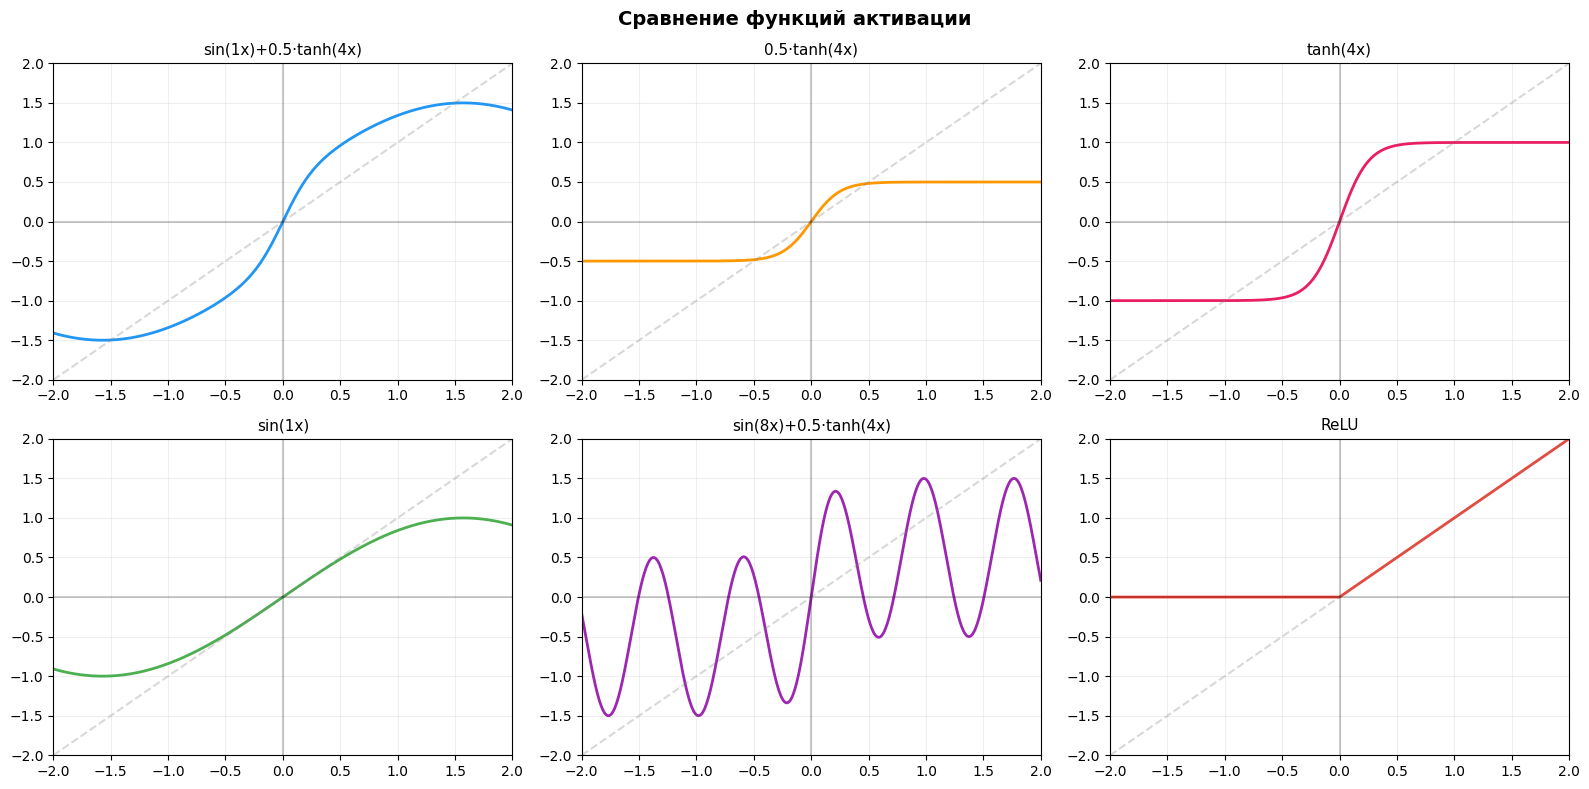

In [ ]:
# === Визуализация функций активации ===
x_range = np.linspace(-2, 2, 500)

activations_plot = {
    'sin(1x)+0.5·tanh(4x)': np.sin(1*x_range) + 0.5*np.tanh(4*x_range),
    '0.5·tanh(4x)':         0.5*np.tanh(4*x_range),
    'tanh(4x)':              np.tanh(4*x_range),
    'sin(1x)':               np.sin(1*x_range),
    'sin(8x)+0.5·tanh(4x)': np.sin(8*x_range) + 0.5*np.tanh(4*x_range),
    'ReLU':                  np.maximum(0, x_range),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
colors = ['#2196F3', '#FF9800', '#E91E63', '#4CAF50', '#9C27B0', '#F44336']

for ax, (name, vals), color in zip(axes.flat, activations_plot.items(), colors):
    ax.plot(x_range, vals, color=color, linewidth=2)
    ax.plot(x_range, x_range, '--', color='gray', alpha=0.3, label='y=x')
    ax.axhline(y=0, color='black', alpha=0.2)
    ax.axvline(x=0, color='black', alpha=0.2)
    ax.set_title(name, fontsize=11)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.grid(True, alpha=0.2)

plt.suptitle('Сравнение функций активации', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# === Эксперимент ===
NUM_RUNS = 5
EPOCHS = 10
BATCH_SIZE = 128

activation_configs = {
    'sin(1x)+0.5·tanh(4x)': {'a': 1.0, 'w': 0.5, 'b': 4.0},
    '0.5·tanh(4x)':         {'a': 0.0, 'w': 0.5, 'b': 4.0},
    'tanh(4x)':              {'a': 0.0, 'w': 1.0, 'b': 4.0},
    'sin(1x)':               {'a': 1.0, 'w': 0.0, 'b': 4.0},
    'sin(8x)+0.5·tanh(4x)': {'a': 8.0, 'w': 0.5, 'b': 4.0},
}

results = {}

for act_name, params in activation_configs.items():
    runs = []
    for run in range(NUM_RUNS):
        np.random.seed(run)
        tf.random.set_seed(run)

        act_fn = make_activation(**params)
        ae, enc = build_chaos_ae(act_fn)
        history = ae.fit(
            x_train, x_train,
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            validation_data=(x_test, x_test),
            verbose=0
        )
        s = analyze_latent(enc, x_test)
        s['val_loss'] = history.history['val_loss'][-1]
        runs.append(s)

        print(f"  {act_name:30s} run {run+1}/{NUM_RUNS}: "
              f"loss={s['val_loss']:.4f}, "
              f"dead={s['dead_neurons']}/128, "
              f"var={s['mean_variance']:.4f}")

        del ae, enc
        keras.backend.clear_session()

    results[act_name] = runs
    print()

# Baseline TopK+ReLU
print("--- Baseline: TopK+ReLU ---")
baseline_runs = []
for run in range(NUM_RUNS):
    np.random.seed(run)
    tf.random.set_seed(run)

    ae, enc = build_topk_relu()
    history = ae.fit(
        x_train, x_train,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_data=(x_test, x_test),
        verbose=0
    )
    s = analyze_latent(enc, x_test)
    s['val_loss'] = history.history['val_loss'][-1]
    baseline_runs.append(s)

    print(f"  {'TopK+ReLU':30s} run {run+1}/{NUM_RUNS}: "
          f"loss={s['val_loss']:.4f}, "
          f"dead={s['dead_neurons']}/128, "
          f"var={s['mean_variance']:.4f}")

    del ae, enc
    keras.backend.clear_session()

results['TopK+ReLU'] = baseline_runs
print("\nAll experiments done.")

2026-04-06 14:36:35.864490: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-06 14:36:35.864512: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-04-06 14:36:35.864515: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-04-06 14:36:35.864530: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-06 14:36:35.864539: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-06 14:36:36.410330: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  sin(1x)+0.5·tanh(4x)           run 1/5: loss=0.0093, dead=0/128, var=0.1653
  sin(1x)+0.5·tanh(4x)           run 2/5: loss=0.0091, dead=0/128, var=0.1572
  sin(1x)+0.5·tanh(4x)           run 3/5: loss=0.0093, dead=0/128, var=0.1688
  sin(1x)+0.5·tanh(4x)           run 4/5: loss=0.0092, dead=0/128, var=0.1666
  sin(1x)+0.5·tanh(4x)           run 5/5: loss=0.0094, dead=0/128, var=0.1695

  0.5·tanh(4x)                   run 1/5: loss=0.0113, dead=1/128, var=0.0212
  0.5·tanh(4x)                   run 2/5: loss=0.0115, dead=4/128, var=0.0212
  0.5·tanh(4x)                   run 3/5: loss=0.0116, dead=4/128, var=0.0218
  0.5·tanh(4x)                   run 4/5: loss=0.0112, dead=6/128, var=0.0212
  0.5·tanh(4x)                   run 5/5: loss=0.0112, dead=2/128, var=0.0209

  tanh(4x)                       run 1/5: loss=0.0135, dead=0/128, var=0.1395
  tanh(4x)                       run 2/5: loss=0.0134, dead=0/128, var=0.1400
  tanh(4x)                       run 3/5: loss=0.0130, dead=0/

In [6]:
# === Сводная таблица ===
print("\n" + "=" * 75)
print("СВОДНАЯ ТАБЛИЦА: ВКЛАД КОМПОНЕНТОВ")
print("=" * 75)
print(f"{'Активация':<30} {'Val Loss':>14} {'Dead':>12} {'Variance':>14}")
print('-' * 75)

summary = {}

for name in list(activation_configs.keys()) + ['TopK+ReLU']:
    runs = results[name]
    l = [r['val_loss'] for r in runs]
    d = [r['dead_neurons'] for r in runs]
    v = [r['mean_variance'] for r in runs]

    summary[name] = {
        'loss_mean': np.mean(l), 'loss_std': np.std(l),
        'dead_mean': np.mean(d), 'dead_std': np.std(d),
        'var_mean': np.mean(v), 'var_std': np.std(v),
        'losses': l, 'deads': d,
    }

    print(f"{name:<30} {np.mean(l):.4f} ± {np.std(l):.4f} "
          f"{np.mean(d):>5.1f} ± {np.std(d):.1f} "
          f"{np.mean(v):.4f} ± {np.std(v):.4f}")

# Ключевой вопрос
print("\n" + "=" * 75)
print("КЛЮЧЕВОЙ ВОПРОС: sin(1x) вносит вклад при a=1?")
print("=" * 75)

full = summary['sin(1x)+0.5·tanh(4x)']
only_tanh = summary['0.5·tanh(4x)']

t_stat, p_val = stats.ttest_ind(full['losses'], only_tanh['losses'], equal_var=False)
print(f"sin(1x)+0.5·tanh(4x): loss = {full['loss_mean']:.4f}")
print(f"0.5·tanh(4x):         loss = {only_tanh['loss_mean']:.4f}")
print(f"Разница: {abs(full['loss_mean'] - only_tanh['loss_mean']):.4f}")
print(f"t-test p-value: {p_val:.6f}")
if p_val < 0.05:
    print("=> ЗНАЧИМАЯ разница: sin(1x) вносит вклад!")
else:
    print("=> Разница НЕ значима: sin(1x) при a=1 не вносит значимого вклада")


СВОДНАЯ ТАБЛИЦА: ВКЛАД КОМПОНЕНТОВ
Активация                            Val Loss         Dead       Variance
---------------------------------------------------------------------------
sin(1x)+0.5·tanh(4x)           0.0093 ± 0.0001   0.0 ± 0.0 0.1655 ± 0.0044
0.5·tanh(4x)                   0.0114 ± 0.0001   3.4 ± 1.7 0.0213 ± 0.0003
tanh(4x)                       0.0133 ± 0.0002   0.0 ± 0.0 0.1399 ± 0.0004
sin(1x)                        0.0067 ± 0.0001   2.4 ± 0.8 0.0402 ± 0.0003
sin(8x)+0.5·tanh(4x)           0.0673 ± 0.0001   0.0 ± 0.0 0.4060 ± 0.0026
TopK+ReLU                      0.0116 ± 0.0005  63.0 ± 6.0 4541.0824 ± 921.5943

КЛЮЧЕВОЙ ВОПРОС: sin(1x) вносит вклад при a=1?
sin(1x)+0.5·tanh(4x): loss = 0.0093
0.5·tanh(4x):         loss = 0.0114
Разница: 0.0021
t-test p-value: 0.000000
=> ЗНАЧИМАЯ разница: sin(1x) вносит вклад!


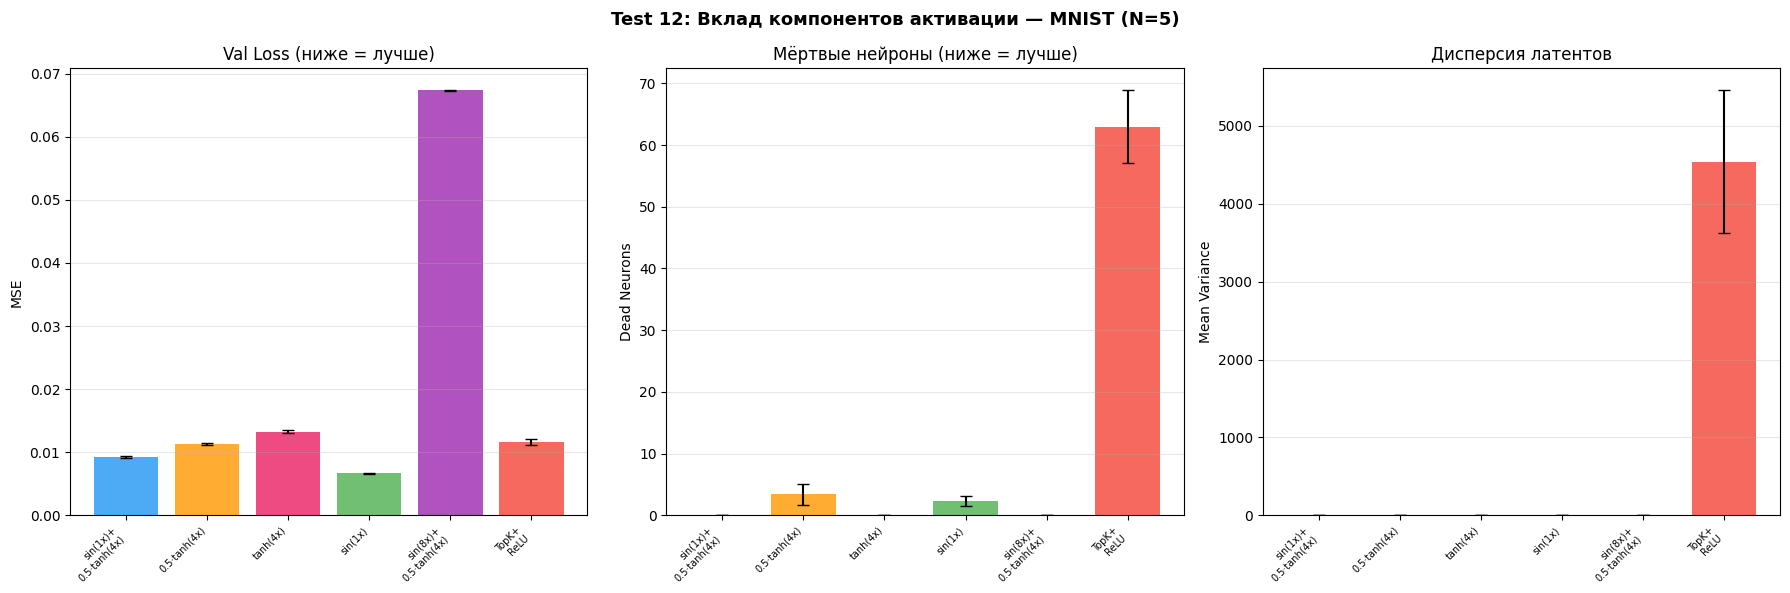

In [7]:
# === Визуализация результатов ===
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

method_names = list(results.keys())
x_pos = np.arange(len(method_names))
colors = ['#2196F3', '#FF9800', '#E91E63', '#4CAF50', '#9C27B0', '#F44336']

# Val Loss
means = [summary[m]['loss_mean'] for m in method_names]
stds = [summary[m]['loss_std'] for m in method_names]
axes[0].bar(x_pos, means, yerr=stds, capsize=4, color=colors, alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([n.replace('+', '+\n') for n in method_names], fontsize=7, rotation=45, ha='right')
axes[0].set_ylabel('MSE')
axes[0].set_title('Val Loss (ниже = лучше)')
axes[0].grid(True, alpha=0.3, axis='y')

# Dead Neurons
means = [summary[m]['dead_mean'] for m in method_names]
stds = [summary[m]['dead_std'] for m in method_names]
axes[1].bar(x_pos, means, yerr=stds, capsize=4, color=colors, alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([n.replace('+', '+\n') for n in method_names], fontsize=7, rotation=45, ha='right')
axes[1].set_ylabel('Dead Neurons')
axes[1].set_title('Мёртвые нейроны (ниже = лучше)')
axes[1].grid(True, alpha=0.3, axis='y')

# Variance
means = [summary[m]['var_mean'] for m in method_names]
stds = [summary[m]['var_std'] for m in method_names]
axes[2].bar(x_pos, means, yerr=stds, capsize=4, color=colors, alpha=0.8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([n.replace('+', '+\n') for n in method_names], fontsize=7, rotation=45, ha='right')
axes[2].set_ylabel('Mean Variance')
axes[2].set_title('Дисперсия латентов')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Test 12: Вклад компонентов активации — MNIST (N={NUM_RUNS})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# === Сохранение результатов ===
save_data = {
    'experiment': 'component_analysis',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'dataset': 'MNIST',
        'num_runs': NUM_RUNS,
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'latent_dim': 128,
        'k_active': 32,
    },
    'activation_configs': activation_configs,
    'results': {name: runs for name, runs in results.items()},
    'summary': {name: {k: v for k, v in s.items() if k not in ('losses', 'deads')}
                for name, s in summary.items()},
}

json_path = f'../jsons/component_analysis_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f"Results saved: {json_path}")

Results saved: ../jsons/component_analysis_20260406_151852.json
